In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [58]:
print("=" * 60)
print("EDA")
print("=" * 60)

EDA


In [59]:
df = pd.read_csv("data/used_cars.csv")
print(df.shape)
print(f"Dataset have {df.shape[0]} rows and {df.shape[1]} colums")
for col in df.columns:
    print(f"Col: {col}")
    
print(df.info())
print(df.describe().round(2))

(1500, 10)
Dataset have 1500 rows and 10 colums
Col: brand
Col: model_year
Col: mileage_km
Col: engine_size_L
Col: fuel_type
Col: transmission
Col: num_owners
Col: accident_history
Col: service_history
Col: price_usd
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             1500 non-null   object 
 1   model_year        1500 non-null   int64  
 2   mileage_km        1442 non-null   float64
 3   engine_size_L     1432 non-null   float64
 4   fuel_type         1500 non-null   object 
 5   transmission      1500 non-null   object 
 6   num_owners        1500 non-null   int64  
 7   accident_history  1500 non-null   int64  
 8   service_history   1189 non-null   object 
 9   price_usd         1500 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 117.3+ KB
None
       model_year  mileage_km  engine_size_

In [60]:
print("5 first rows")
print(df.head())

5 first rows
     brand  model_year  mileage_km  engine_size_L fuel_type transmission  \
0     Ford        2021     41658.0            2.0    Diesel    Automatic   
1      Kia        2013    151762.0            3.0    Petrol    Automatic   
2    Mazda        2006    200465.0            2.0    Petrol       Manual   
3  Hyundai        2022     38038.0            1.2    Petrol    Automatic   
4    Honda        2013         NaN            1.6    Petrol    Automatic   

   num_owners  accident_history service_history  price_usd  
0           1                 1            Full      30700  
1           3                 0             NaN      19600  
2           2                 0         Partial      14600  
3           2                 0         Partial      31700  
4           2                 0             NaN      26200  


In [61]:
print("Check missing value")
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"Column have missing value {col} with {round((df[col].isnull().sum() / len(df) * 100),2)} %")

Check missing value
brand                 0
model_year            0
mileage_km           58
engine_size_L        68
fuel_type             0
transmission          0
num_owners            0
accident_history      0
service_history     311
price_usd             0
dtype: int64
Column have missing value mileage_km with 3.87 %
Column have missing value engine_size_L with 4.53 %
Column have missing value service_history with 20.73 %


In [62]:
print("Check duplicate value")
print(df.duplicated().sum())

Check duplicate value
0


In [63]:
numerics_columns = df.select_dtypes(['float64', 'int64']).columns

for col in numerics_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    
    if outliers.sum() > 0:
        print(f"Outliers in {col}: {outliers.sum()}")
    
    # median = df[col].median()
    
    # df[col].apply(
    #     lambda x: median if (x < lower_bound or x > upper_bound) else x 
    # )
    
    df[col] = df[col].clip(lower= lower_bound, upper=upper_bound)

Outliers in mileage_km: 10
Outliers in engine_size_L: 134
Outliers in num_owners: 86


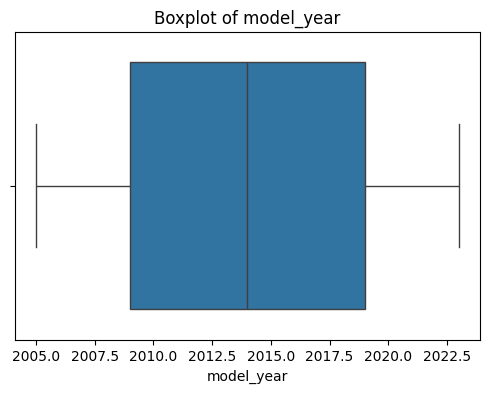

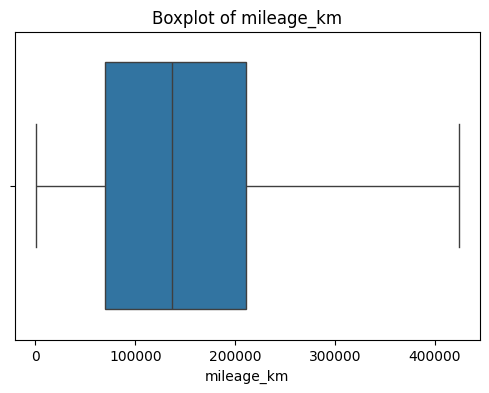

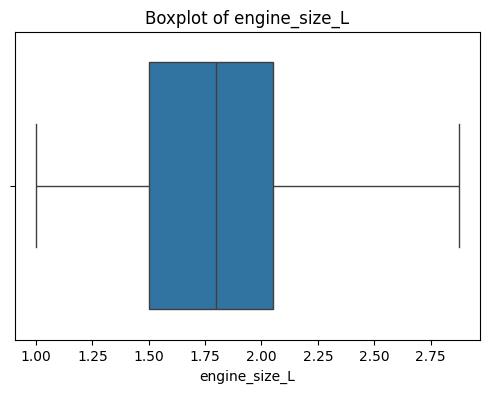

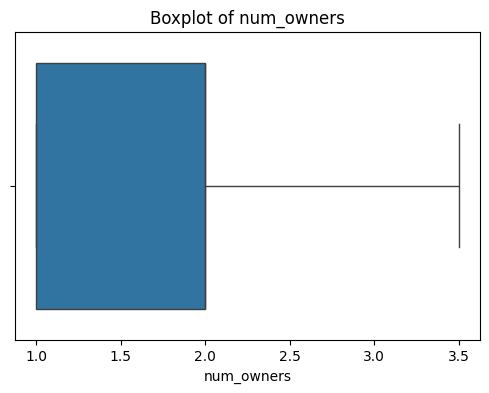

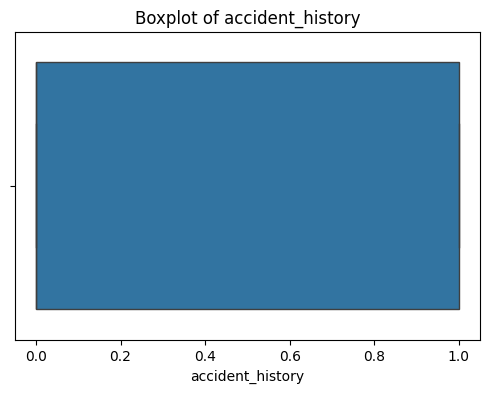

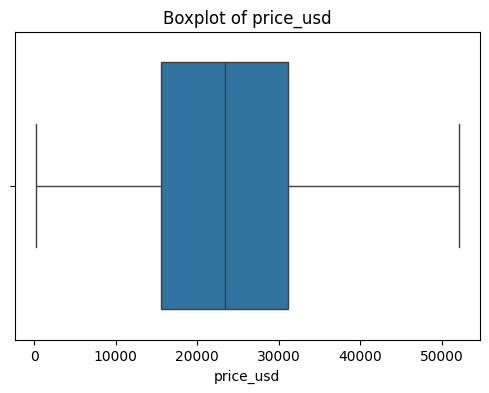

In [64]:
for col in numerics_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    

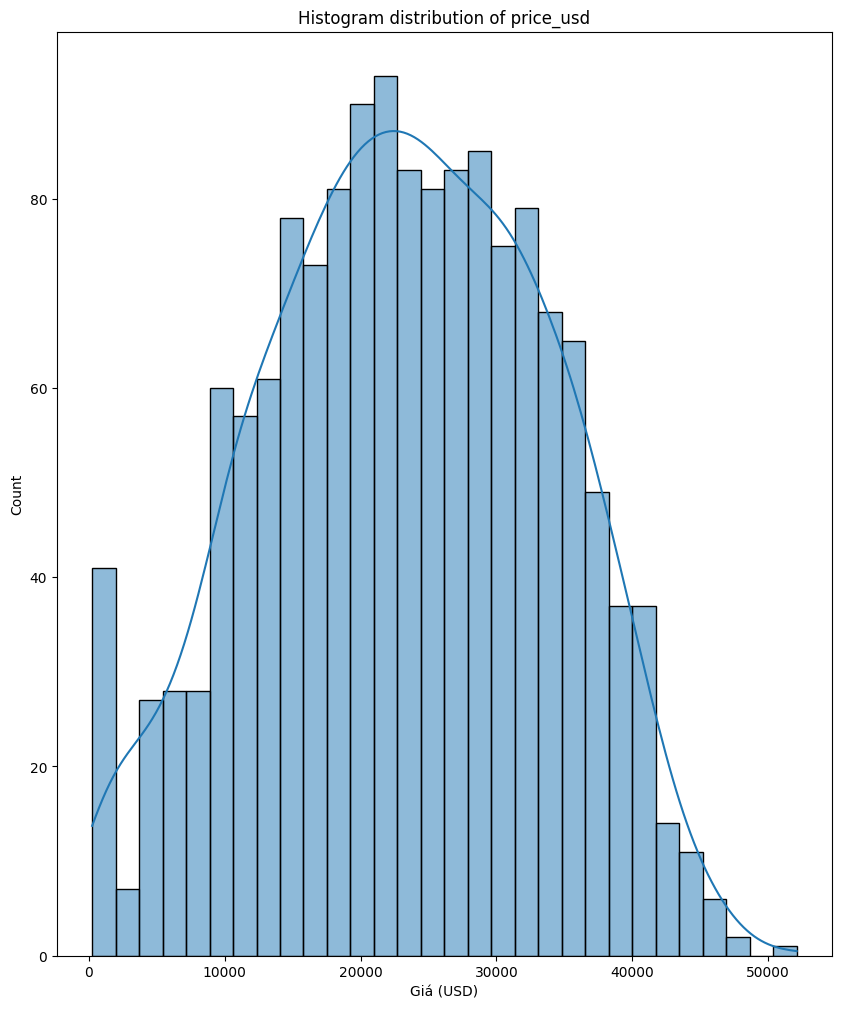

In [65]:
plt.figure(figsize=(10,12))

sns.histplot(
    data = df,
    x ='price_usd',
    kde= True,
    bins = 30,
)
plt.title('Histogram distribution of price_usd')
plt.xlabel('Giá (USD)')
plt.show()

In [66]:
print(df['brand'].value_counts)

<bound method IndexOpsMixin.value_counts of 0          Ford
1           Kia
2         Mazda
3       Hyundai
4         Honda
         ...   
1495    Hyundai
1496    Hyundai
1497        BMW
1498       Ford
1499     Nissan
Name: brand, Length: 1500, dtype: object>


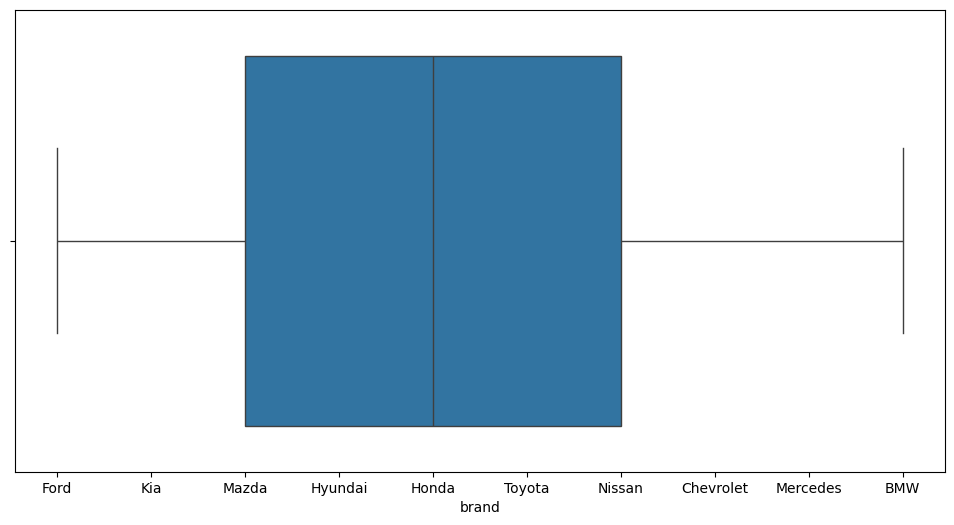

In [67]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data = df,
    x = 'brand'
)
plt.show()

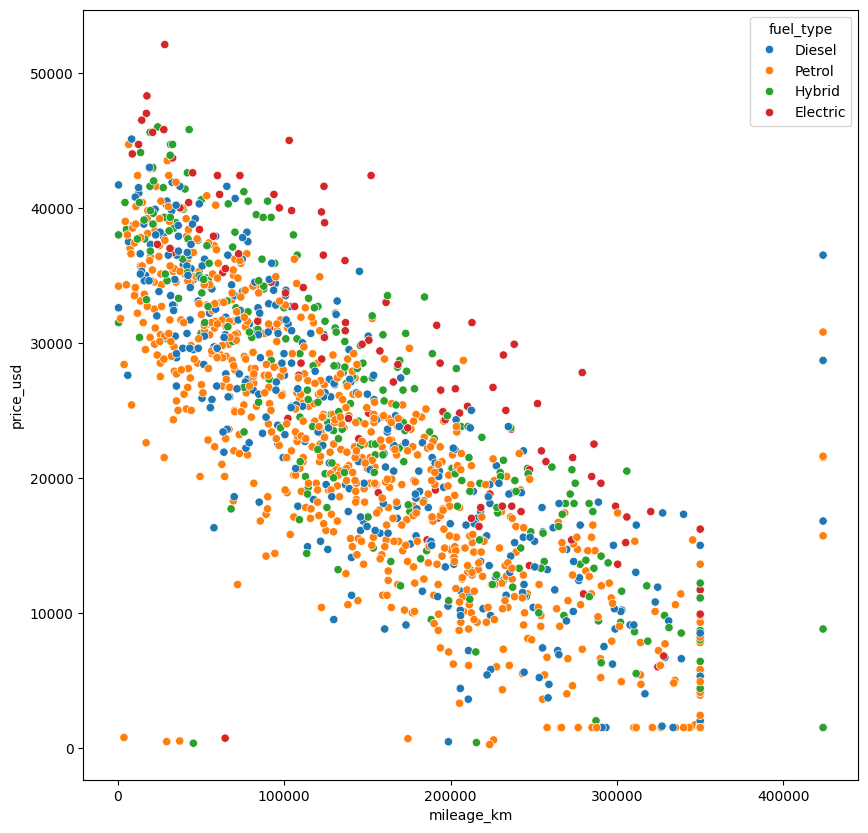

In [68]:
plt.figure(figsize=(10,10))
sns.scatterplot(
    data = df,
    x = "mileage_km",
    y = "price_usd",
    hue = "fuel_type"
)
plt.show()

In [69]:
print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

PREPROCESSING


In [104]:
outlier_indices = df[(df['mileage_km'] > 400000) | (df['price_usd'] < 1000)].index
print(f"Delete {len(outlier_indices)} rows")
df = df.drop(outlier_indices).reset_index(drop=True)

Delete 0 rows


In [71]:
print(df['service_history'].value_counts())

service_history
Full       641
Partial    532
Name: count, dtype: int64


In [105]:
df['service_history'] = df['service_history'].fillna("Full")
df['mileage_km'] = df['mileage_km'].fillna(df['mileage_km'].median())
df['engine_size_L'] = df['engine_size_L'].fillna(df.groupby('brand')['engine_size_L'].transform('median'))

In [106]:
df['car_age'] = 2026 - df['model_year']
df['mileage_per_year'] = df['mileage_km'] / (df['car_age'] + 1)

In [ ]:
print("Encoding categorical columns...")

# Bước A: OneHot cho 'brand'
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df[['brand']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['brand']))

df_merged = pd.concat([df.drop('brand', axis=1), encoded_df], axis=1)

cols_to_encode = ['fuel_type', 'transmission', 'service_history']
df_final = pd.get_dummies(
    df_merged, 
    columns=cols_to_encode, 
    drop_first=True,   
    prefix=cols_to_encode 
)

print(f"Số lượng giá trị Null trong df_final: {df_final.isnull().sum().sum()}")

Encoding categorical columns...
Số lượng giá trị Null trong df_final: 0


In [108]:
print("=" * 60)
print("TRAINING")
print("=" * 60)

TRAINING


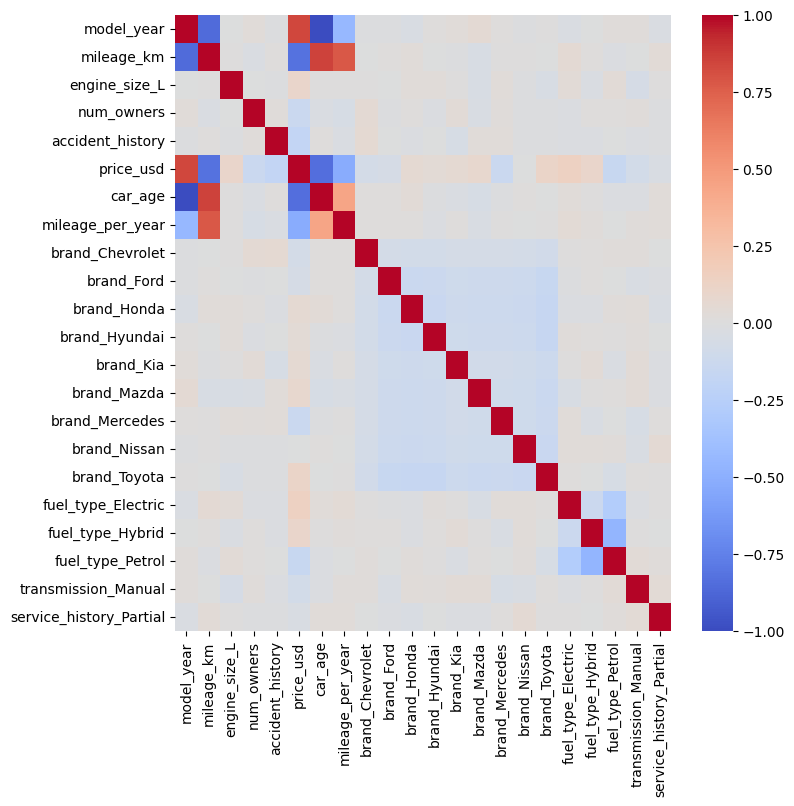

In [109]:
plt.figure(figsize=(8, 8))
sns.heatmap(df_final.corr(numeric_only=True), cmap='coolwarm') # car age va km co ve da cong tuyen, giu 1 cot
plt.show()

In [119]:
features = [
    'car_age', 'mileage_km', 'mileage_per_year', 
    # 'engine_size_L', 'num_owners', 'accident_history',
    # 'brand_Chevrolet', 'brand_Ford', 'brand_Honda', 
    # 'brand_Hyundai', 'brand_Kia', 'brand_Mazda', 
    # 'brand_Mercedes', 'brand_Nissan', 'brand_Toyota'
]

X = df_final[features]

y = df_final['price_usd']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [121]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaler, y_train)

LinearRegression()

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

y_train_pred = model.predict(X_train_scaler)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"{'Metric':<20}{'Train':>20}{'Test':>10}")
print("-" * 42)
print(f"{'MSE':<20}{mse_test:>10.4f}{mse_test:>10.4f}")
print(f"{'RMSE':<20}{np.sqrt(mse_train):>10.4f}{rmse_test:>10.4f}")
print(f"{'R²':<20}{r2_train:>10.4f}{r2_test:>10.4f}")

Metric                             Train      Test
------------------------------------------
MSE                 25445652.470425445652.4704
RMSE                 5088.5776 5044.3684
R²                      0.7499    0.7624


C:\Users\lequa\AppData\Local\Temp\ipykernel_18620\1603782189.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, ax=axes[2], palette='viridis')


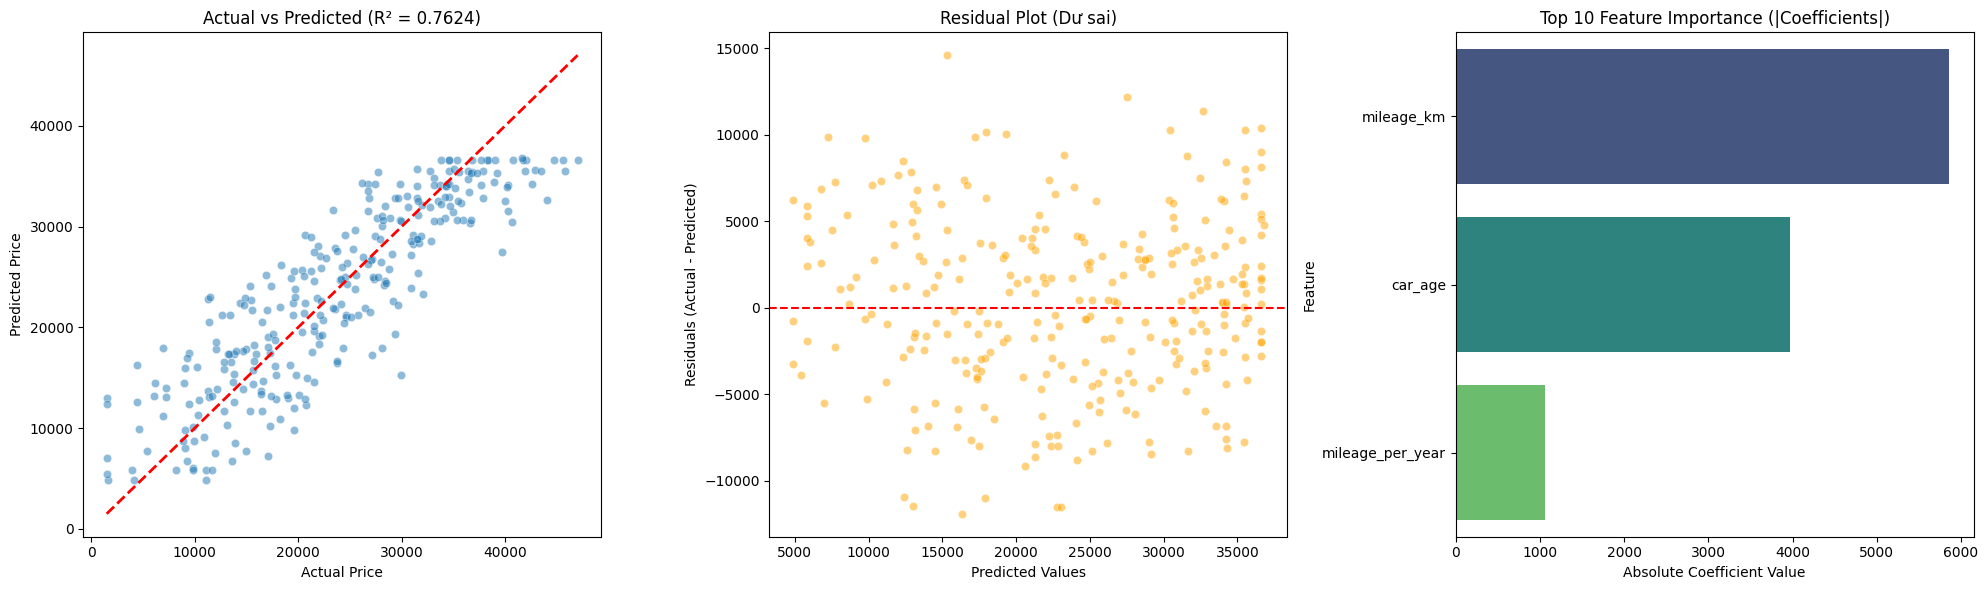

In [ ]:
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred


coeffs = model.coef_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(coeffs)
}).sort_values(by='Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted (R² = {r2_test:.4f})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='orange', alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residual Plot (Dư sai)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

sns.barplot(x='Importance', y='Feature', data=feature_importance, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Feature Importance (|Coefficients|)')
axes[2].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()
plt.show()

PHẦN 1: EDA
Shape: (1500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             1500 non-null   object 
 1   model_year        1500 non-null   int64  
 2   mileage_km        1442 non-null   float64
 3   engine_size_L     1432 non-null   float64
 4   fuel_type         1500 non-null   object 
 5   transmission      1500 non-null   object 
 6   num_owners        1500 non-null   int64  
 7   accident_history  1500 non-null   int64  
 8   service_history   1189 non-null   object 
 9   price_usd         1500 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 117.3+ KB

None

       model_year  mileage_km  engine_size_L  num_owners  accident_history  \
count     1500.00     1442.00        1432.00     1500.00           1500.00   
mean      2014.02   149859.26           1.87        1.81              0.

C:\Users\lequa\AppData\Local\Temp\ipykernel_18620\57542403.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='brand', y='price_usd', ax=axes[1], palette='Set2')


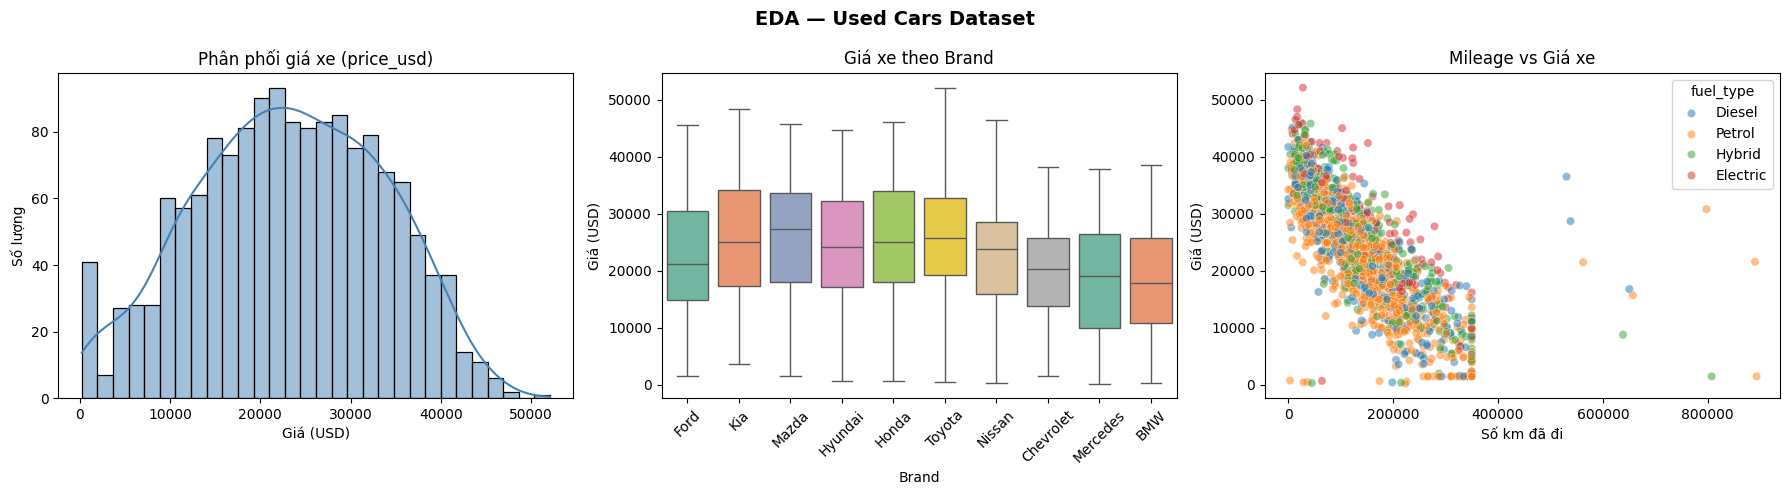

✅ Saved: output/eda_charts.png

PHẦN 2: PREPROCESSING
Dropped 20 outlier rows → còn 1480 rows
Missing sau khi fill: 0
Sau khi drop model_year: (1480, 11)
Shape sau encoding: (1480, 21)
Null còn lại: 0

PHẦN 3: TRAIN & EVALUATE
Features sử dụng (20 cột): ['mileage_km', 'engine_size_L', 'num_owners', 'accident_history', 'car_age', 'mileage_per_year', 'brand_Chevrolet', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Kia', 'brand_Mazda', 'brand_Mercedes', 'brand_Nissan', 'brand_Toyota', 'fuel_type_Electric', 'fuel_type_Hybrid', 'fuel_type_Petrol', 'transmission_Manual', 'service_history_Partial']

Train: 1184 | Test: 296

Metric                     Train        Test
--------------------------------------------
MSE                      6637317     7535633
RMSE                     2576.30     2745.11
R²                        0.9359      0.9296

📊 Diễn giải:
  • R² test = 0.930 → model giải thích 93.0% sự biến thiên của giá xe
  • RMSE = $2,745 → trung bình mỗi dự đoán lệch ±$2,745
  •

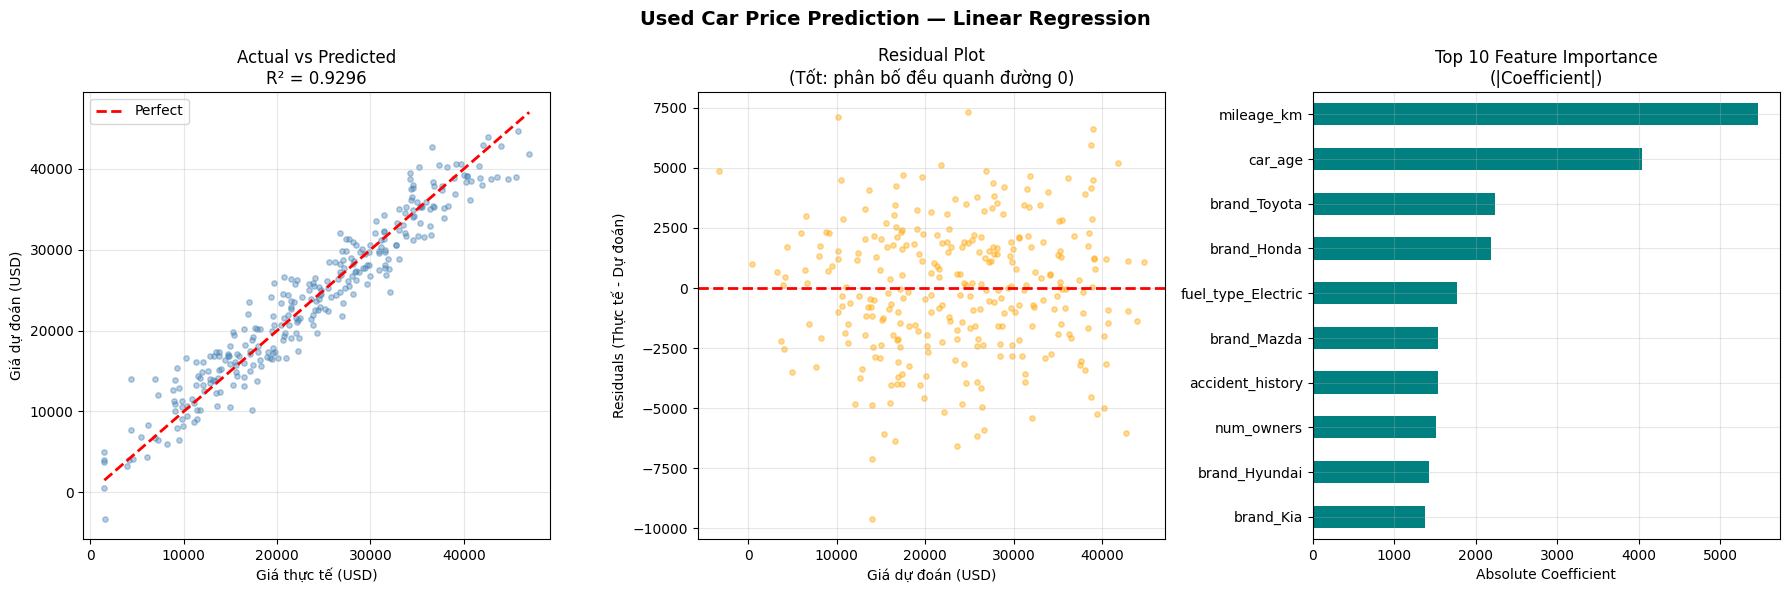

✅ Saved: output/model_charts.png

--- Bonus: Dự đoán xe mới ---
  Toyota 2019 | 65,000km | Petrol → $35,800.0
  BMW 2015 | 120,000km | Petrol → $20,000.0
  Ford 2010 | 200,000km | Diesel → $12,500.0


In [128]:
# ============================================================
# LỜI GIẢI CHUẨN — Dự đoán giá xe cũ
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# PHẦN 1 — EDA
# ============================================================
print("=" * 60)
print("PHẦN 1: EDA")
print("=" * 60)

df = pd.read_csv("data/used_cars.csv")

# 1.1 Thông tin cơ bản
print(f"Shape: {df.shape}")
print(f"\n{df.info()}")
print(f"\n{df.describe().round(2)}")
print(f"\n5 dòng đầu:\n{df.head()}")

# 1.2 Missing values — đếm và tính %
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
print(missing_report[missing_report['Count'] > 0])

# 1.3 Duplicate
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 1.4 Outliers bằng IQR
print("\n--- Outlier Detection (IQR Method) ---")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outliers (lower={lower:.0f}, upper={upper:.0f})")

# 1.5 Vẽ 3 biểu đồ EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Histogram price_usd
sns.histplot(df['price_usd'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title("Phân phối giá xe (price_usd)")
axes[0].set_xlabel("Giá (USD)")
axes[0].set_ylabel("Số lượng")

# Chart 2: Boxplot price_usd theo brand — ĐỂ Y LÀ price_usd
sns.boxplot(data=df, x='brand', y='price_usd', ax=axes[1], palette='Set2')
axes[1].set_title("Giá xe theo Brand")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Giá (USD)")
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Scatter mileage vs price tô màu theo fuel_type
sns.scatterplot(data=df, x='mileage_km', y='price_usd',
                hue='fuel_type', alpha=0.5, ax=axes[2])
axes[2].set_title("Mileage vs Giá xe")
axes[2].set_xlabel("Số km đã đi")
axes[2].set_ylabel("Giá (USD)")

plt.suptitle("EDA — Used Cars Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/eda_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/eda_charts.png")

# ============================================================
# PHẦN 2 — PREPROCESSING
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 2: PREPROCESSING")
print("=" * 60)

# BƯỚC QUAN TRỌNG: Drop outliers TRƯỚC KHI fill missing
# Lý do: nếu fill trước, giá trị bất thường sẽ ảnh hưởng đến median
before = len(df)
df = df[(df['mileage_km'].isna()) | (df['mileage_km'] <= 400_000)]
df = df[df['price_usd'] >= 1_000]
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} outlier rows → còn {len(df)} rows")

# 2.2 Fill missing values
# mileage_km: median theo từng brand (xe cùng brand có km sử dụng tương tự nhau)
df['mileage_km'] = df['mileage_km'].fillna(
    df.groupby('brand')['mileage_km'].transform('median')
)

# engine_size_L: median tổng thể (không đủ thông tin để group)
df['engine_size_L'] = df['engine_size_L'].fillna(df['engine_size_L'].median())

# service_history: mode (giá trị phổ biến nhất)
df['service_history'] = df['service_history'].fillna(df['service_history'].mode()[0])

print(f"Missing sau khi fill: {df.isnull().sum().sum()}")  # Phải = 0

# 2.3 Feature Engineering
df['car_age'] = 2024 - df['model_year']
df['mileage_per_year'] = df['mileage_km'] / (df['car_age'] + 1)

# 2.4 Drop model_year (đã có car_age rồi, 2 cột này mang thông tin giống nhau)
df = df.drop(columns=['model_year'])
print(f"Sau khi drop model_year: {df.shape}")

# 2.5 Encode tất cả categorical cùng 1 lúc bằng get_dummies
# drop_first=True: tránh dummy variable trap (multicollinearity)
df_final = pd.get_dummies(
    df,
    columns=['brand', 'fuel_type', 'transmission', 'service_history'],
    drop_first=True
)
print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

# ============================================================
# PHẦN 3 — TRAIN & EVALUATE
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 3: TRAIN & EVALUATE")
print("=" * 60)

# Dùng TẤT CẢ features (không comment bỏ)
X = df_final.drop(columns=['price_usd'])
y = df_final['price_usd']

print(f"Features sử dụng ({X.shape[1]} cột): {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# StandardScaler: fit chỉ trên train để tránh data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Metrics
y_train_pred = model.predict(X_train_s)
y_test_pred  = model.predict(X_test_s)

mse_train  = mean_squared_error(y_train, y_train_pred)
mse_test   = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test, y_test_pred)

print(f"\n{'Metric':<20}{'Train':>12}{'Test':>12}")
print("-" * 44)
print(f"{'MSE':<20}{mse_train:>12.0f}{mse_test:>12.0f}")
print(f"{'RMSE':<20}{rmse_train:>12.2f}{rmse_test:>12.2f}")
print(f"{'R²':<20}{r2_train:>12.4f}{r2_test:>12.4f}")

# Diễn giải kết quả (QUAN TRỌNG — phải giải thích được)
print(f"""
📊 Diễn giải:
  • R² test = {r2_test:.3f} → model giải thích {r2_test*100:.1f}% sự biến thiên của giá xe
  • RMSE = ${rmse_test:,.0f} → trung bình mỗi dự đoán lệch ±${rmse_test:,.0f}
  • R² train ({r2_train:.3f}) ≈ R² test ({r2_test:.3f}) → KHÔNG overfitting
    (nếu train >> test thì mới là overfitting)
""")

# ============================================================
# PHẦN 4 — VISUALIZATION
# ============================================================
print("=" * 60)
print("PHẦN 4: VISUALIZATION")
print("=" * 60)

residuals = y_test - y_test_pred

# Feature importance
fi = pd.Series(np.abs(model.coef_), index=X.columns)
fi_top10 = fi.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.4, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel("Giá thực tế (USD)")
axes[0].set_ylabel("Giá dự đoán (USD)")
axes[0].set_title(f"Actual vs Predicted\nR² = {r2_test:.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Residual Plot
axes[1].scatter(y_test_pred, residuals, alpha=0.4, s=15, color='orange')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel("Giá dự đoán (USD)")
axes[1].set_ylabel("Residuals (Thực tế - Dự đoán)")
axes[1].set_title("Residual Plot\n(Tốt: phân bố đều quanh đường 0)")
axes[1].grid(True, alpha=0.3)

# Chart 3: Top 10 Feature Importance
fi_top10.sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title("Top 10 Feature Importance\n(|Coefficient|)")
axes[2].set_xlabel("Absolute Coefficient")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Used Car Price Prediction — Linear Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/model_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/model_charts.png")

# ============================================================
# BONUS 3 — Predict function
# ============================================================
def predict_car_price(brand, model_year, mileage_km,
                      engine_size_L, fuel_type, transmission,
                      num_owners, accident_history, service_history):
    """Dự đoán giá 1 xe mới dựa trên model đã train."""
    input_dict = {
        'mileage_km': [mileage_km],
        'engine_size_L': [engine_size_L],
        'num_owners': [num_owners],
        'accident_history': [accident_history],
        'car_age': [2024 - model_year],
        'mileage_per_year': [mileage_km / (2024 - model_year + 1)],
        'brand': [brand],
        'fuel_type': [fuel_type],
        'transmission': [transmission],
        'service_history': [service_history],
    }
    input_df = pd.DataFrame(input_dict)

    # Encode giống như training data
    input_encoded = pd.get_dummies(
        input_df,
        columns=['brand', 'fuel_type', 'transmission', 'service_history']
    )

    # Align columns với training data (thêm cột thiếu = 0)
    input_aligned = input_encoded.reindex(columns=X.columns, fill_value=0)

    input_scaled = scaler.transform(input_aligned)
    price = model.predict(input_scaled)[0]
    return max(0, round(price, -2))

# Test function
test_cases = [
    dict(brand='Toyota', model_year=2019, mileage_km=65000, engine_size_L=2.0,
         fuel_type='Petrol', transmission='Automatic', num_owners=1,
         accident_history=0, service_history='Full'),
    dict(brand='BMW', model_year=2015, mileage_km=120000, engine_size_L=3.0,
         fuel_type='Petrol', transmission='Automatic', num_owners=2,
         accident_history=1, service_history='Partial'),
    dict(brand='Ford', model_year=2010, mileage_km=200000, engine_size_L=1.6,
         fuel_type='Diesel', transmission='Manual', num_owners=3,
         accident_history=0, service_history='None'),
]

print("\n--- Bonus: Dự đoán xe mới ---")
for tc in test_cases:
    price = predict_car_price(**tc)
    print(f"  {tc['brand']} {tc['model_year']} | {tc['mileage_km']:,}km | "
          f"{tc['fuel_type']} → ${price:,}")